# 03 Vergleichzahl

Ziel dieses Notebooks ist eine Vergleichszahl. Erst wenn feststeht, was einfache Verfahren auf diesen Daten erreichen, lässt sich beurteilen, ob ein komplexes Modell seinen Aufwand wert ist.

Ein einzelner Wert wie **0,74 PR-AUC** lässt sich erst durch einen Vergleich sinnvoll einordnen. Dafür werden geeignete Referenzmodelle herangezogen. Gleichzeitig stellt sich die Frage, ob die gewählte Modellierung tatsächlich einen zusätzlichen Nutzen gegenüber einfacheren Verfahren bietet.


Drei Vergleichspunkte werden gebaut, in aufsteigender Ernsthaftigkeit:

| Vergleichspunkt | Was er darstellt |
|---|---|
| **Kein Alarm** |  gar nichts tun |
| **Zufall** | raten im richtigen Klassenverhältnis |
| **Logistische Regression** | die einfachste ernsthafte Lösung |

Bewertet wird auf der **Validierungsmenge**. 

In [1]:
import pandas as pd

from src.data.split import lade_teilmengen, trenne_merkmale_und_ziel
from src.data.validate import load_params
from src.modeling.baseline import baue_baselines, bewerte
from src.utils.plotting import FARBEN, nur_x_gitter, setze_stil, speichere

import matplotlib.pyplot as plt

setze_stil()
params = load_params()
seed = params["seed"]
kosten = params["costs"]

train, val, _ = lade_teilmengen()
X_train, y_train = trenne_merkmale_und_ziel(train, params)
X_val, y_val = trenne_merkmale_und_ziel(val, params)

print(f"Training    : {len(y_train)} Zeilen, {int(y_train.sum())} Ausfälle")
print(f"Validierung : {len(y_val)} Zeilen, {int(y_val.sum())} Ausfälle")

Training    : 7000 Zeilen, 237 Ausfälle
Validierung : 1500 Zeilen, 51 Ausfälle


### Womit gerechnet wird

Neben den Modellkennzahlen wird in diesem Notebook eine Kostenspalte geführt.
Sie übersetzt die Verwechslungsmatrix in Euro — also in die Größe, über die im
Betrieb tatsächlich entschieden wird. Die Sätze stammen aus `params.yaml` und
sind eine begründete Annahme.

In [2]:
kosten_tabelle = pd.DataFrame(
    {
        "Fall": [
            "Ausfall übersehen (FN)",
            "Fehlalarm (FP)",
            "Ausfall erkannt, geplant gewartet (TP)",
            "zu Recht kein Alarm (TN)",
        ],
        "Kosten je Fall in €": [
            kosten["false_negative_eur"],
            kosten["false_positive_eur"],
            kosten["true_positive_eur"],
            0,
        ],
    }
).set_index("Fall")

# Ab welcher Ausfallwahrscheinlichkeit lohnt sich ein Alarm rechnerisch?

schwelle_lohnend = kosten["false_positive_eur"] / (
    kosten["false_negative_eur"] - kosten["true_positive_eur"] + kosten["false_positive_eur"]
)

print("Verhältnis übersehener Ausfall zu Fehlalarm: "
      f"{kosten['false_negative_eur'] / kosten['false_positive_eur']:.0f} zu 1")
print("Ein Alarm lohnt sich rechnerisch ab einer Ausfallwahrscheinlichkeit von "
      f"{schwelle_lohnend:.1%}")

kosten_tabelle

Verhältnis übersehener Ausfall zu Fehlalarm: 20 zu 1
Ein Alarm lohnt sich rechnerisch ab einer Ausfallwahrscheinlichkeit von 5.2%


,Kosten je Fall in €
Fall,
Ausfall übersehen (FN),10000
Fehlalarm (FP),500
"Ausfall erkannt, geplant gewartet (TP)",800
zu Recht kein Alarm (TN),0


Ein übersehener Ausfall kostet das **Zwanzigfache** eines Fehlalarms. Und
rechnerisch lohnt sich ein Alarm bereits ab **5,2 %** geschätzter
Ausfallwahrscheinlichkeit — nicht erst ab 50 %, wie `predict()` es
voreingestellt tut. Diese Zahl ist keine Schätzung, sie folgt direkt aus den
Kostensätzen oben.

## 1 Vergleichspunkte

Alle drei werden auf denselben Daten trainiert und auf denselben Daten bewertet.
Der Schwellenwert steht vorerst auf 0,5 — der voreingestellte Wert, den
`predict()` stillschweigend benutzt. Dass er für dieses Problem falsch ist, wird
gleich sichtbar.

In [3]:
ergebnisse = [
    bewerte(pipeline, X_train, y_train, X_val, y_val, kosten, bezeichnung)
    for bezeichnung, pipeline in baue_baselines(X_train, seed).items()
]

baselines = pd.DataFrame(ergebnisse).set_index("Modell")
baselines.round(3)

,PR-AUC,ROC-AUC,Recall,Precision,Kosten EUR
Modell,,,,,
Kein Alarm (immer 0),0.034,0.500,0.000,0.000,510000.0
Zufall (stratifiziert),0.037,0.522,0.078,0.073,498700.0
Logistische Regression,0.357,0.843,0.157,0.800,437400.0


**Die PR-AUC des Zufallsmodells liegt bei 0,037 — und das ist kein Zufall.** Bei
einer Precision-Recall-Kurve entspricht das Niveau des reinen Ratens dem Anteil
der positiven Klasse, hier 3,4 %. Das ist die **Nulllinie** der Metrik: Was
darauf liegt, misst nichts. Anders als bei ROC-AUC, wo die Nulllinie immer bei
0,5 liegt, verschiebt sie sich bei PR-AUC mit der Seltenheit der Ereignisse.

In [4]:
anteil_positiv = float(y_train.mean())
pr_auc_zufall = float(baselines.loc["Zufall (stratifiziert)", "PR-AUC"])

print(f"Anteil positiver Fälle im Training : {anteil_positiv:.3f}")
print(f"PR-AUC des Zufallsmodells          : {pr_auc_zufall:.3f}")
print(f"Abweichung                         : {abs(pr_auc_zufall - anteil_positiv):.3f}")

Anteil positiver Fälle im Training : 0.034
PR-AUC des Zufallsmodells          : 0.037
Abweichung                         : 0.003


Die beiden Werte stimmen bis auf Rundung überein — ein nützlicher
Plausibilitätstest: Weicht die PR-AUC eines Zufallsmodells deutlich vom
Klassenanteil ab, stimmt etwas mit der Aufteilung oder der Bewertung nicht.

## 2 Vergleichzahl

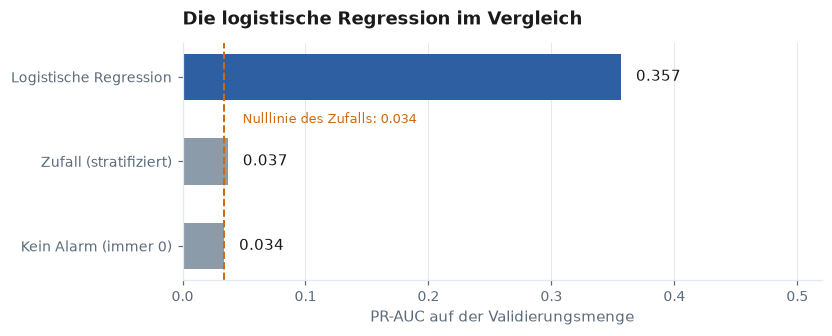

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 2.8))

reihenfolge = baselines.sort_values("PR-AUC")
positionen = range(len(reihenfolge))
farben = [FARBEN["neutral"], FARBEN["neutral"], FARBEN["kein_ausfall"]]

ax.barh(list(positionen), reihenfolge["PR-AUC"], height=0.55, color=farben)
for pos, wert in zip(positionen, reihenfolge["PR-AUC"]):
    ax.text(wert + 0.012, pos, f"{wert:.3f}", va="center", ha="left",
            fontsize=10, color=FARBEN["text"])

ax.axvline(anteil_positiv, color=FARBEN["ausfall"], linewidth=1.3, linestyle="--")
# Beschriftung in die Lücke zwischen zwei Balken, nicht an den oberen Rand.
ax.text(anteil_positiv + 0.015, 1.5, f"Nulllinie des Zufalls: {anteil_positiv:.3f}",
        fontsize=8.5, color=FARBEN["ausfall"], va="center", ha="left")

ax.set_yticks(list(positionen), list(reihenfolge.index))
ax.set_xlim(0, 0.52)
ax.set_xlabel("PR-AUC auf der Validierungsmenge")
ax.set_title("Die logistische Regression im Vergleich", loc="left")
nur_x_gitter(ax)

speichere(fig, "09_baselines_pr_auc")
plt.show()

Die logistische Regression erreicht eine **PR-AUC von 0,357** und liegt damit deutlich über dem Zufallsniveau von etwa 0,034. Damit dient sie als sinnvolle **Baseline für den Modellvergleich**. Ein komplexeres Modell sollte daher nicht nur gegenüber dem Zufallsmodell bewertet werden, sondern auch zeigen, dass es gegenüber der logistischen Regression einen zusätzlichen Nutzen bietet.


## 3 Der Schwellenwert 0,5 ist sichtbar falsch

Die Kennzahlen bei einem Schwellenwert von 0,5 zeigen ein anderes Bild. Die logistische Regression erreicht eine **Precision von 0,800**. Wenn das Modell einen Alarm ausgibt, ist dieser in den meisten Fällen tatsächlich mit einem Ausfall verbunden. Gleichzeitig liegt der **Recall nur bei 0,157**. Das Modell erkennt somit lediglich einen kleinen Teil der tatsächlich auftretenden Ausfälle.

Diese Ergebnisse hängen wesentlich von der gewählten Entscheidungsschwelle ab. Da nur **3,4 %** der Fälle zur positiven Klasse gehören, liegen die vom Modell berechneten Wahrscheinlichkeiten häufig unter dem Schwellenwert von 0,5. In diesen Fällen wird kein Alarm ausgelöst, obwohl tatsächlich ein Ausfall vorliegt. Dadurch können relevante Ausfälle unentdeckt bleiben, was sich auch auf die wirtschaftliche Bewertung des Modells auswirkt.

In [6]:
kosten_spalte = baselines[["Recall", "Precision", "Kosten EUR"]].copy()
kosten_spalte["Ersparnis gegenüber Nichtstun"] = (
    baselines.loc["Kein Alarm (immer 0)", "Kosten EUR"] - baselines["Kosten EUR"]
)
kosten_spalte.round(3)

,Recall,Precision,Kosten EUR,Ersparnis gegenüber Nichtstun
Modell,,,,
Kein Alarm (immer 0),0.000,0.000,510000.0,0.0
Zufall (stratifiziert),0.078,0.073,498700.0,11300.0
Logistische Regression,0.157,0.800,437400.0,72600.0


Nichtstun kostet in der Validierungsmenge **510.000 €** — 51 übersehene Ausfälle
zu je 10.000 €. Die logistische Regression bei Schwelle 0,5 kommt auf 437.400 €,
spart also nur rund **73.000 €**. Für ein Modell, das die Klassen erkennbar
trennt (ROC-AUC 0,843), ist das erstaunlich wenig.

Der Grund ist allein der Schwellenwert. Bei einem Kostenverhältnis von 20 zu 1
ist Schweigen die teuerste Option — und 0,5 lässt das Modell fast immer
schweigen. .

> `predict()` benutzt stillschweigend 0,5. Das ist eine Voreinstellung, keine
> Entscheidung.

Jedes Modell der folgenden Etappen wird gegen diese Tabelle gestellt. Die
entscheidende Zahl ist **PR-AUC 0,357**.

Ein Hinweis: Ein Random Forest hat auf denselben Merkmalen bereits **0,738** erreicht — mehr als das Doppelte der logistischen Regression. Das ist der gemessene Beleg für die Vermutung aus Notebook 01: 
Die Ausfälle liegen an beiden Rändern des Betriebsbereichs, und eine gerade
Trennlinie kann das nicht abbilden. Der Aufwand für ein Baumverfahren ist damit
gerechtfertigt, weil es nachweislich mehr kann.

---

## Summary

| Vergleichspunkt | PR-AUC | Recall @ 0,5 | Kosten |
|---|---|---|---|
| Kein Alarm | 0,034 | 0,000 | 510.000 € |
| Zufall (stratifiziert) | 0,037 | 0,078 | 498.700 € |
| **Logistische Regression** | **0,357** | 0,157 | 437.400 € |

**PR-AUC 0,357.**

Die Nulllinie der PR-AUC liegt bei dieser Klassenverteilung bei 0,034, nicht bei 0,5. Und der voreingestellte
Schwellenwert 0,5 verschenkt bei ungleichen Fehlerkosten den größten Teil des möglichen Nutzens.

Die Kennzahlen liegen als `reports/baseline_results.json` vor.